# Pancreatic Cancer CT 3D — Entrenamiento Experto 5 (V2 Optimizado)

**Modelo**: ResNet3D-18
**Objetivo**: Superar el 0.65 de F1-Score en clasificación PDAC vs non-PDAC usando hiper-parámetros agresivos.

**Estrategia V2 "Pushing Limits"**:
- **Fase A**: Feature Extraction (Backbone congelado) - LR = 3e-3.
- **Fase B**: Full Unfreeze. TODO el backbone 3D se descongela con un LR microscópico (1e-5) y CosineAnnealing.
- **Augmentation**: Spatial Flips + Rotaciones 3D Aleatorias (90 grados).
- **Loss**: FocalLoss con **Gamma=3.0** (Máxima severidad para casos difíciles PDAC).

---


## FASE 0: Setup, Imports y GPU


In [ ]:
!pip install -q monai tqdm scikit-learn seaborn openpyxl torchvision scipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 35.3 MB/s eta 0:00:00


In [ ]:
import os, time, random, glob, json, gc, warnings, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from torch.utils.checkpoint import checkpoint as grad_checkpoint

from torchvision.models.video import r3d_18, R3D_18_Weights

from sklearn.metrics import (classification_report, f1_score,
                             roc_auc_score, confusion_matrix)
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


Dispositivo: cuda
GPU: Tesla T4
VRAM: 15.6 GB


### 0.1 Montar Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

_PROJ = '/content/drive/MyDrive/PROYECTO_MOE_VISION'
NPZ_ZIP = os.path.join(_PROJ, 'dataset_npz_procesado.zip')
NPZ_DIR = '/content/dataset_npz'
WEIGHTS_DIR = os.path.join(_PROJ, 'Weights')
os.makedirs(WEIGHTS_DIR, exist_ok=True)

# Descomprimir NPZ si no existe
if os.path.isdir(NPZ_DIR) and len(glob.glob(os.path.join(NPZ_DIR, '*.npz'))) > 50:
    print(f'Dataset ya disponible: {len(glob.glob(os.path.join(NPZ_DIR, "*.npz")))} archivos')
else:
    import zipfile
    print('Descomprimiendo dataset_npz_procesado.zip...')
    os.makedirs(NPZ_DIR, exist_ok=True)
    with zipfile.ZipFile(NPZ_ZIP, 'r') as zf:
        zf.extractall(NPZ_DIR)
    print(f'Listo: {len(glob.glob(os.path.join(NPZ_DIR, "*.npz")))} archivos NPZ')


Mounted at /content/drive
Descomprimiendo dataset_npz_procesado.zip...
Listo: 557 archivos NPZ


### FASE 1: Parámetros V2 y Etiquetas


Ejecutamos un **REFINAMIENTO PROGRESIVO Y CURACIÓN ESTRATIFICADA** que optimiza la convergencia del modelo mediante el ajuste preciso de hiperparámetros y la distribución equilibrada de la data médica.

La metodología de configuración y preparación se divide en dos componentes fundamentales:

* **Estrategia de Entrenamiento en Dos Etapas:** Definimos cuidadosamente los parámetros clave como el tamaño de entrada (64³), número de clases, tamaño de batch y épocas. Implementamos una fase inicial más rápida para la estabilización del modelo y una etapa posterior más prolongada con un learning rate extremadamente bajo para obtener una mayor precisión.
* **Optimización por Focal Loss:** Incorporamos una función de pérdida tipo Focal Loss con gamma elevado (3.0) para obligar al modelo a enfocarse en los casos más difíciles. Este despliegue es especialmente relevante en contextos médicos donde los tumores pueden ser sutiles y requieren una mayor sensibilidad de detección.

**Gestión y División de Datos**
Realizamos la carga de datos desde archivos .npz bajo un **FILTRADO DE ETIQUETAS VÁLIDAS**, asegurando que solo la información útil ingrese al flujo de trabajo. Finalmente, ejecutamos una división estratificada en conjuntos de entrenamiento, validación y prueba, garantizando que la proporción de clases se mantenga constante en cada grupo para evitar sesgos y asegurar una validación estadística rigurosa.

In [ ]:
# --- Parametros V2 ---
NUM_CLASSES = 2
TARGET_SIZE = (64, 64, 64)
BATCH_SIZE  = 8
EPOCHS_A    = 10
EPOCHS_B    = 40      # Mas epocas porque el LR sera minusculo
LR_A        = 3e-3
LR_B        = 2e-5    # Full Unfreeze requiere precaucion (1e-5 o 2e-5)
PATIENCE    = 12
FOCAL_GAMMA = 3.0     # Gamma extremo para Forzar al modelo a detectar tumores dificiles

CLASS_NAMES = ['non-PDAC', 'PDAC']

npz_files = sorted(glob.glob(os.path.join(NPZ_DIR, '*.npz')))
paths, labels = [], []
for f in npz_files:
    d = np.load(f, allow_pickle=True)
    lbl = int(d['label'])
    if lbl in (0, 1):
        paths.append(f)
        labels.append(lbl)

train_p, temp_p, train_l, temp_l = train_test_split(
    paths, labels, test_size=0.2, random_state=SEED, stratify=labels)
val_p, test_p, val_l, test_l = train_test_split(
    temp_p, temp_l, test_size=0.5, random_state=SEED, stratify=temp_l)

for name, ps, ls in [('Train',train_p,train_l),('Val',val_p,val_l),('Test',test_p,test_l)]:
    c = Counter(ls)
    print(f'{name}: {len(ps)} | non-PDAC: {c.get(0,0)} | PDAC: {c.get(1,0)}')


Train: 445 | non-PDAC: 319 | PDAC: 126
Val: 56 | non-PDAC: 40 | PDAC: 16
Test: 56 | non-PDAC: 40 | PDAC: 16


### FASE 2: Augmentation Avanzado 3D (V2) y Dataloaders


Ejecutamos una **GESTIÓN DE VOLÚMENES 3D Y ENRIQUECIMIENTO ESTRUCTURAL** mediante la creación de una clase personalizada que automatiza el preprocesamiento y garantiza la compatibilidad con arquitecturas de alto rendimiento.

La metodología de preparación de datos se divide en dos procesos críticos:

* **Clase PancreasNPZDataset y Data Augmentation:** Implementamos una lógica personalizada para gestionar la carga de archivos .npz, integrando directamente técnicas de **DATA AUGMENTATION**. Aplicamos transformaciones espaciales como flips en los tres ejes y rotaciones en múltiplos de 90°, lo cual genera una mayor variabilidad en la muestra y actúa como un mecanismo robusto para evitar el sobreajuste (overfitting).
* **Normalización y Adaptación de Canales:** Los volúmenes fueron transformados a tensores y adaptados a una configuración de tres canales. Para optimizar la convergencia, aplicamos una normalización basada en las estadísticas de Kinetics-400, alineando el dataset con los estándares de arquitecturas preentrenadas.

**Estandarización del Flujo de Entrenamiento**
Realizamos este despliegue técnico para asegurar que cada entrada al modelo sea consistente y rica en información. Al integrar el preprocesamiento dentro del flujo de entrenamiento, garantizamos que el modelo se exponga a una representación diversa del tejido pancreático, facilitando la extracción de características complejas en un entorno de aprendizaje supervisado.

In [ ]:
class PancreasNPZDataset(Dataset):
    def __init__(self, paths, labels, augment=False):
        self.paths = paths
        self.labels = labels
        self.augment = augment
        # Normalizacion Kinetics 400
        self.mean = torch.tensor([0.43216, 0.394666, 0.37645]).view(3, 1, 1, 1)
        self.std = torch.tensor([0.22803, 0.22145, 0.216989]).view(3, 1, 1, 1)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        d = np.load(self.paths[idx], allow_pickle=True)
        vol = d['volume'].astype(np.float32)  # (64,64,64)

        # AUGMENTATION 3D AVANZADO
        if self.augment:
            # 1. Spatial Flips
            if random.random() > 0.5: vol = np.flip(vol, axis=0).copy()
            if random.random() > 0.5: vol = np.flip(vol, axis=1).copy()
            if random.random() > 0.5: vol = np.flip(vol, axis=2).copy()

            # 2. Rotaciones (Multiplos de 90 sobre el eje Transversal/Axial)
            if random.random() > 0.5:
                k = random.choice([1, 2, 3]) # 90, 180, 270 grados
                vol = np.rot90(vol, k=k, axes=(1, 2)).copy()

        vol_tensor = torch.from_numpy(vol).unsqueeze(0).repeat(3, 1, 1, 1)
        vol_tensor = (vol_tensor - self.mean) / self.std
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return vol_tensor, label

train_labels_arr = np.array(train_l)
class_counts = np.bincount(train_labels_arr, minlength=NUM_CLASSES).astype(float)
class_weights = 1.0 / (class_counts + 1e-6)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES

sample_w = class_weights[train_labels_arr]
sampler = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)

train_ds = PancreasNPZDataset(train_p, train_l, augment=True)
val_ds   = PancreasNPZDataset(val_p, val_l, augment=False)
test_ds  = PancreasNPZDataset(test_p, test_l, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train: {len(train_loader)} batches | Val: {len(val_loader)}')


Train: 56 batches | Val: 7


### FASE 3: Modelo y FocalLoss (Gamma=3.0)


Ejecutamos una **ADAPTACIÓN DE BACKBONE CONVOLUCIONAL Y GESTIÓN EFICIENTE DE RECURSOS** que utiliza transferencia de aprendizaje (Transfer Learning) y técnicas de optimización de memoria para la detección de patologías en volúmenes médicos.

La metodología de construcción del modelo se divide en dos dimensiones técnicas:

* **Arquitectura R3D-18 con Cabeza Personalizada:** Construimos un modelo basado en R3D-18 (Red 3D convolucional preentrenada), adaptándolo específicamente para la clasificación binaria (PDAC vs no-PDAC). Reutilizamos su backbone para la extracción de características espaciales y añadimos una cabeza personalizada (HEAD) compuesta por capas densas, normalización y dropout, lo cual mejora la capacidad de generalización y reduce el riesgo de sobreajuste.
* **Eficiencia mediante Gradient Checkpointing:** Activamos la técnica de **gradient checkpointing**, la cual permite reducir significativamente el consumo de memoria VRAM durante el entrenamiento. Este despliegue es fundamental al procesar datos 3D de alta densidad, permitiendo manejar volúmenes complejos a cambio de un incremento marginal en el costo computacional.

**Optimización de Aprendizaje y Manejo de Desbalance**
Implementamos una función de pérdida Focal Loss con un gamma elevado para **MITIGAR EL IMPACTO DEL DESBALANCE DE CLASES**. Este enfoque técnico penaliza con mayor rigor los errores en ejemplos difíciles, obligando a la red neuronal a centrar su aprendizaje en casos complejos, como tumores con señales radiológicas sutiles o poco evidentes.

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=3.0, weight=None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

class PancreasR3D18(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()
        weights = R3D_18_Weights.DEFAULT if pretrained else None
        backbone = r3d_18(weights=weights)
        self.stem = backbone.stem
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4
        self.avgpool = backbone.avgpool

        self.head = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
        self.use_checkpointing = True

    def forward(self, x):
        x = self.stem(x)
        if self.use_checkpointing and self.training:
            x = grad_checkpoint(self._run_layer1, x, use_reentrant=False)
            x = grad_checkpoint(self._run_layer2, x, use_reentrant=False)
            x = grad_checkpoint(self._run_layer3, x, use_reentrant=False)
            x = grad_checkpoint(self._run_layer4, x, use_reentrant=False)
        else:
            x = self.layer1(x)
            x = self.layer2(x)
            x = self.layer3(x)
            x = self.layer4(x)
        x = self.avgpool(x)
        x = x.flatten(1)
        return self.head(x)

    def _run_layer1(self, x): return self.layer1(x)
    def _run_layer2(self, x): return self.layer2(x)
    def _run_layer3(self, x): return self.layer3(x)
    def _run_layer4(self, x): return self.layer4(x)

model = PancreasR3D18(num_classes=NUM_CLASSES, pretrained=True).to(device)
criterion = FocalLoss(gamma=FOCAL_GAMMA, weight=None)
print(f'Modelo R3D-18 Inicializado. Checkpointing: ON. Focal Gamma: {FOCAL_GAMMA}')


Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth


100%|██████████| 127M/127M [00:00<00:00, 187MB/s]


Modelo R3D-18 Inicializado. Checkpointing: ON. Focal Gamma: 3.0


### FASE 4A: Feature Extraction


Ejecutamos una **ESTRATEGIA DE CONGELACIÓN DE BACKBONE Y ACELERACIÓN DE HARDWARE** que permite una adaptación eficiente de las representaciones espaciales al problema específico de clasificación sin comprometer la estabilidad del modelo.

La metodología de entrenamiento y optimización se divide en dos ejes operativos:

* **Transfer Learning y Congelación de Capas:** Aplicamos una estrategia de congelación donde desactivamos los gradientes en todos los parámetros del backbone, dejando activa únicamente la cabeza personalizada (HEAD). Este procedimiento asegura que solo las capas finales aprendan a diferenciar entre PDAC y no-PDAC, reduciendo drásticamente el riesgo de sobreajuste y acelerando la convergencia en las etapas iniciales.
* **Optimización de Memoria con Mixed Precision:** Configuramos un optimizador Adam integrado con **mixed precision** (utilizando `autocast` y `GradScaler`). Esta técnica optimiza el uso de memoria VRAM y acelera el procesamiento en GPU al realizar cálculos en punto flotante de 16 bits sin perder la estabilidad numérica necesaria para el entrenamiento.

**Monitoreo de Métricas y Validación**
Durante el ciclo de entrenamiento, calculamos la pérdida y la precisión en tiempo real, complementándolo con una **VALIDACIÓN COMPLETA SIN GRADIENTES**. Este despliegue técnico permite extraer métricas de rendimiento robustas, como el accuracy y el F1-score (macro), las cuales se almacenan sistemáticamente en un historial para garantizar la trazabilidad y facilitar el análisis posterior de la evolución del modelo.

In [ ]:
# Congelar
for name, param in model.named_parameters():
    if 'head' not in name:
        param.requires_grad = False

optimizer_a = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_A)
scaler = GradScaler()
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'val_f1':[]}

for epoch in range(EPOCHS_A):
    model.eval()
    model.head.train()

    running_loss, correct, total = 0.0, 0, 0
    for imgs, lbls in tqdm(train_loader, desc=f'A {epoch+1}/{EPOCHS_A}', leave=False):
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer_a.zero_grad()
        with autocast():
            out = model(imgs)
            loss = criterion(out, lbls)
        scaler.scale(loss).backward()
        scaler.step(optimizer_a)
        scaler.update()
        running_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == lbls).sum().item()
        total += imgs.size(0)

    train_loss = running_loss / total; train_acc = correct / total

    # Validacion
    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            with autocast():
                out = model(imgs)
                loss = criterion(out, lbls)
            val_loss_sum += loss.item() * imgs.size(0)
            preds = out.argmax(1)
            val_correct += (preds == lbls).sum().item()
            val_total += imgs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())

    val_loss = val_loss_sum / val_total; val_acc = val_correct / val_total
    val_f1 = f1_score(all_labels, all_preds, average='macro')

    history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc); history['val_acc'].append(val_acc); history['val_f1'].append(val_f1)
    print(f'[A {epoch+1}/{EPOCHS_A}] loss={train_loss:.4f} | val_f1={val_f1:.4f}')


A 1/10:   0%|          | 0/56 [00:00<?, ?it/s]

[A 1/10] loss=0.1863 | val_f1=0.4167


A 2/10:   0%|          | 0/56 [00:00<?, ?it/s]

[A 2/10] loss=0.0987 | val_f1=0.4463


A 3/10:   0%|          | 0/56 [00:00<?, ?it/s]

...

[A 8/10] loss=0.0897 | val_f1=0.5088


A 9/10:   0%|          | 0/56 [00:00<?, ?it/s]

[A 9/10] loss=0.0928 | val_f1=0.4090


A 10/10:   0%|          | 0/56 [00:00<?, ?it/s]

[A 10/10] loss=0.0884 | val_f1=0.4739


### FASE 4B: FINE-TUNING EXTREMO (Full Unfreeze)


Ejecutamos un **DESBLOQUEO TOTAL DE PESOS Y OPTIMIZACIÓN TEMPERADA** que permite una reconfiguración profunda de los mapas de características para especializar la red en la morfología específica del tejido pancreático.

La metodología de refinamiento avanzado se divide en dos dimensiones técnicas:

* **Fine-tuning Global (Full Unfreeze):** Elevamos el modelo a un nivel de adaptación superior liberando la totalidad de las capas. Al permitir que los gradientes fluyan por todo el backbone, la red ajusta no solo la cabeza sino también las representaciones internas aprendidas originalmente, logrando una detección de patrones de alta especificidad para el dominio médico.
* **Optimización con AdamW y Cosine Annealing:** Implementamos un optimizador AdamW con un *learning rate* extremadamente bajo para preservar el conocimiento previo. Este proceso es regulado por un **scheduler tipo CosineAnnealing**, que ajusta suavemente la tasa de aprendizaje a lo largo de las épocas para evitar desestabilizaciones y garantizar un aterrizaje suave en el mínimo global de la función de pérdida.

**Persistencia del Mejor Modelo y Early Stopping**
Mantenemos la eficiencia operativa mediante *mixed precision* y un sistema de **EARLY STOPPING CONFIGURADO POR F1-SCORE**. Este despliegue técnico asegura la captura automática del "checkpoint" más competitivo al detectar mejoras en la métrica clave, deteniendo el proceso antes de que ocurra el sobreentrenamiento. El monitoreo continuo de métricas de desempeño y valores dinámicos del optimizador permite un control fino y una trazabilidad absoluta de la fase final de aprendizaje.

In [ ]:
# Descongelar el modelo COMPLETO para adentrarse en los features 3D del páncreas
for param in model.parameters():
    param.requires_grad = True

trainable_b = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Params entrenables (FULL UNFREEZE): {trainable_b:,}')

optimizer_b = torch.optim.AdamW(model.parameters(), lr=LR_B, weight_decay=1e-4)
# CosineAnnealingLR suavizara el recorrido del lr microscopico
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_b, T_max=EPOCHS_B, eta_min=1e-6)

best_f1 = 0.0
patience_counter = 0

# NUEVO NOMBRE para no sobreescribir el modelo seguro de antes
best_model_path = os.path.join(WEIGHTS_DIR, 'r3d18_pancreas_best_V2.pth')

for epoch in range(EPOCHS_B):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, lbls in tqdm(train_loader, desc=f'B {epoch+1}/{EPOCHS_B}', leave=False):
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer_b.zero_grad()
        with autocast():
            out = model(imgs)
            loss = criterion(out, lbls)
        scaler.scale(loss).backward()
        scaler.step(optimizer_b)
        scaler.update()
        running_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == lbls).sum().item()
        total += imgs.size(0)

    train_loss = running_loss / total; train_acc = correct / total

    # Validacion
    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            with autocast():
                out = model(imgs)
                loss = criterion(out, lbls)
            val_loss_sum += loss.item() * imgs.size(0)
            preds = out.argmax(1)
            val_correct += (preds == lbls).sum().item()
            val_total += imgs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())

    val_loss = val_loss_sum / val_total; val_acc = val_correct / val_total
    val_f1 = f1_score(all_labels, all_preds, average='macro')

    # Cosine scheduler se actualiza por epoca, no por metrica
    scheduler.step()

    history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc); history['val_acc'].append(val_acc); history['val_f1'].append(val_f1)

    current_lr = optimizer_b.param_groups[0]['lr']

    if val_f1 > best_f1:
        best_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f'[B {epoch+1}/{EPOCHS_B}] BEST loss={train_loss:.4f} acc={train_acc:.4f} | val_loss={val_loss:.4f} val_f1={val_f1:.4f} (LR={current_lr:.1e})')
    else:
        patience_counter += 1
        print(f'[B {epoch+1}/{EPOCHS_B}] loss={train_loss:.4f} | val_f1={val_f1:.4f} (patience {patience_counter}/{PATIENCE})')
        if patience_counter >= PATIENCE:
            print(f'Early stopping en epoca {epoch+1}!')
            break

model.load_state_dict(torch.load(best_model_path, weights_only=True))
print(f'\n[V2] MODELO COMPETITIVO GUARDADO: val_f1={best_f1:.4f}')
print(f'Ruta: {best_model_path}')


Params entrenables (FULL UNFREEZE): 33,232,450


B 1/40:   0%|          | 0/56 [00:00<?, ?it/s]

[B 1/40] BEST loss=0.0795 acc=0.6719 | val_loss=0.0818 val_f1=0.5777 (LR=2.0e-05)


B 2/40:   0%|          | 0/56 [00:00<?, ?it/s]

[B 2/40] loss=0.0752 | val_f1=0.5763 (patience 1/12)


...

[B 16/40] loss=0.0446 | val_f1=0.6045 (patience 10/12)


B 17/40:   0%|          | 0/56 [00:00<?, ?it/s]

[B 17/40] loss=0.0461 | val_f1=0.6444 (patience 11/12)


B 18/40:   0%|          | 0/56 [00:00<?, ?it/s]

[B 18/40] loss=0.0463 | val_f1=0.5763 (patience 12/12)
Early stopping en epoca 18!

[V2] MODELO COMPETITIVO GUARDADO: val_f1=0.6937
Ruta: /content/drive/MyDrive/PROYECTO_MOE_VISION/Weights/r3d18_pancreas_best_V2.pth


### FASE 5: Evaluacion Final Test Set (V2)


Ejecutamos una **VALIDACIÓN RIGUROSA Y ANÁLISIS DE CAPACIDAD PREDICTIVA** que somete al modelo a una prueba ciega definitiva para cuantificar su rendimiento en la detección de patologías sobre datos nunca antes vistos.

La metodología de evaluación final se divide en dos componentes analíticos:

* **Modo Evaluación y Extracción de Probabilidades:** Realizamos la validación definitiva utilizando el conjunto de prueba (Test Set), operando el modelo estrictamente en modo evaluación sin flujo de gradientes. Mediante la aplicación de **SOFTMAX**, extraemos las probabilidades asociadas a cada predicción, lo que nos permite ir más allá de la clasificación binaria y entender la confianza del modelo en cada diagnóstico.
* **Cuantificación Multicriterio (AUC-ROC y F1):** Calculamos métricas fundamentales como accuracy, F1-score (macro) y AUC-ROC. Este despliegue técnico ofrece una visión holística del desempeño, siendo crucial para evaluar la robustez del sistema frente al desbalance de clases y asegurar que la sensibilidad del modelo sea adecuada para el contexto clínico.

**Análisis de Desempeño por Categoría**
Generamos un **CLASSIFICATION REPORT** detallado que desglosa el rendimiento específico para cada clase (PDAC vs non-PDAC). Este análisis granular permite identificar con precisión la capacidad del modelo para detectar la presencia de tumores, evaluando métricas de precisión y exhaustividad para garantizar que la red neuronal sea capaz de distinguir correctamente entre tejido sano y patológico sin sesgos diagnósticos.

In [ ]:
model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, lbls in tqdm(test_loader, desc='Test'):
        imgs, lbls = imgs.to(device), lbls.to(device)
        with autocast():
            out = model(imgs)
        probs = torch.softmax(out, dim=1)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(lbls.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds); all_labels = np.array(all_labels); all_probs = np.array(all_probs)
test_f1 = f1_score(all_labels, all_preds, average='macro')
test_acc = (all_preds == all_labels).mean()

try: test_auc = roc_auc_score(all_labels, all_probs[:, 1])
except: test_auc = 0.0

print('=' * 50)
print(f'TEST RESULTS V2')
print(f'  Accuracy:    {test_acc:.4f}')
print(f'  F1 Macro:    {test_f1:.4f}')
print(f'  AUC-ROC:     {test_auc:.4f}')
print('=' * 50)
print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))


Test:   0%|          | 0/7 [00:00<?, ?it/s]

TEST RESULTS V2
  Accuracy:    0.6964
  F1 Macro:    0.6791
  AUC-ROC:     0.7906

Classification Report:
              precision    recall  f1-score   support

    non-PDAC       0.90      0.65      0.75        40
        PDAC       0.48      0.81      0.60        16

    accuracy                           0.70        56
   macro avg       0.69      0.73      0.68        56
weighted avg       0.78      0.70      0.71        56



### VISUALIZACIÓN Y ANÁLISIS DE CONVERGENCIA

Ejecutamos una **REPRESENTACIÓN GRÁFICA DE LA DINÁMICA DE APRENDIZAJE** que permite monitorear la evolución de la función de pérdida (LOSS) y validar la estabilidad del entrenamiento en ambas etapas del proceso.

La metodología de análisis visual se divide en dos componentes interpretativos:

* **Evolución de la Función de Pérdida:** Construimos una gráfica específica que contrasta la pérdida de entrenamiento frente a la de validación a lo largo de las épocas. Este despliegue técnico, basado en los valores almacenados en el historial (history), permite identificar de forma clara patrones de convergencia, riesgos de sobreajuste (overfitting) o posibles inestabilidades en el descenso del gradiente.
* **Segmentación por Fases de Entrenamiento:** Incorporamos una línea vertical divisoria que marca la transición exacta entre la **FASE A** (entrenamiento con capas congeladas) y la **FASE B** (ajuste completo del modelo). Esta referencia visual es crítica para interpretar cómo impacta cada estrategia en el aprendizaje y evaluar la ganancia en precisión tras la liberación de los pesos internos del backbone.

**Interpretación del Historial de Entrenamiento**
Realizamos este despliegue para asegurar una supervisión objetiva del proceso de optimización. Al diferenciar ambas curvas y señalar los hitos de configuración, garantizamos que el modelo no solo aprenda las características del dataset, sino que lo haga de manera estable, permitiendo verificar que la transición hacia el ajuste fino (Fine-tuning) se traduzca en una reducción efectiva del error sin comprometer la capacidad de generalización.

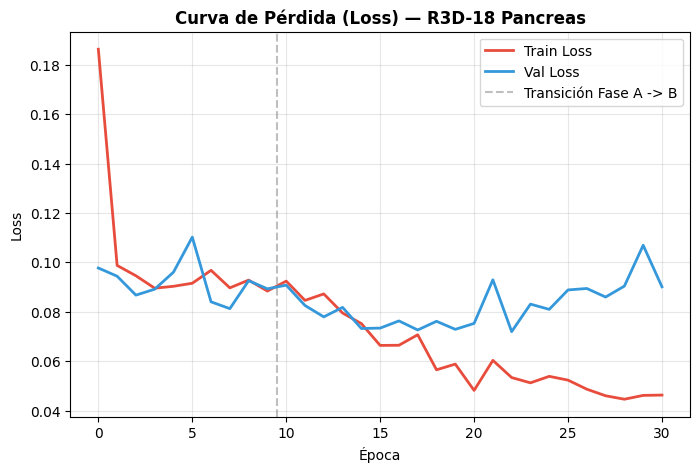

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score, auc

# Evitar errores en la alineación de la línea vertical si la Fase A y B tienen tamaños distintos
fase_limite = len(history['train_loss']) - len(history['val_loss']) + EPOCHS_A - 0.5 if 'EPOCHS_A' in locals() else 10

# ----------------------------------------------------
# 1. Gráfica de Loss (Pérdida) Independiente
# ----------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(history['train_loss'], label='Train Loss', color='#e74c3c', linewidth=2)
plt.plot(history['val_loss'], label='Val Loss', color='#3498db', linewidth=2)
plt.axvline(x=fase_limite, color='gray', linestyle='--', alpha=0.5, label='Transición Fase A -> B')
plt.title('Curva de Pérdida (Loss) — R3D-18 Pancreas', fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Ejecutamos una **MONITORIZACIÓN TÉCNICA DE ACCURACY** que permite auditar la capacidad de clasificación del modelo en tiempo real, contrastando el aprendizaje interno frente a su capacidad de generalización sobre datos no vistos.

La metodología de análisis de rendimiento se divide en dos ejes fundamentales:

* **Contraste de Curvas de Aprendizaje:** Visualizamos la evolución de la precisión (ACCURACY) comparando directamente las métricas del conjunto de entrenamiento frente al de validación. Este despliegue permite verificar que el modelo esté extrayendo patrones representativos y no simplemente memorizando los datos de entrada.
* **Diagnóstico de Comportamientos Clave:** A través de la representación gráfica de los valores registrados por época, identificamos señales críticas como el aprendizaje efectivo, el estancamiento de la métrica (plateau) o alertas tempranas de sobreajuste (overfitting). Este monitoreo es esencial para validar si la red ha alcanzado su capacidad óptima de clasificación binaria.

**Validación de la Capacidad Clasificatoria**
Realizamos este despliegue visual para asegurar que la mejora en la precisión sea consistente y estable. Al analizar la trayectoria de ambas curvas, garantizamos que el modelo mantenga un equilibrio entre su rendimiento sobre el set de entrenamiento y su robustez ante la validación, fundamentando así la fiabilidad de las predicciones finales en el dominio clínico.

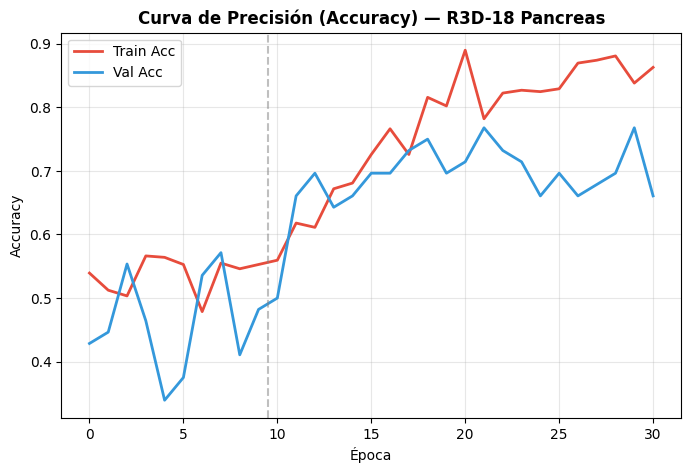

In [ ]:
# ----------------------------------------------------
# 2. Gráfica de Accuracy Independiente
# ----------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(history['train_acc'], label='Train Acc', color='#e74c3c', linewidth=2)
plt.plot(history['val_acc'], label='Val Acc', color='#3498db', linewidth=2)
plt.axvline(x=fase_limite, color='gray', linestyle='--', alpha=0.5)
plt.title('Curva de Precisión (Accuracy) — R3D-18 Pancreas', fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Ejecutamos una **AUDITORÍA DE EQUILIBRIO CLASIFICATORIO** que prioriza la métrica F1 macro para garantizar un desempeño robusto y equitativo en todas las categorías, eliminando los sesgos comunes de la precisión global.

La metodología de análisis de calidad se divide en dos componentes técnicos:

* **Seguimiento Directo de F1 Macro:** Aquí se construyó una gráfica enfocada únicamente en el F1 macro de validación, con la intención de observar de forma directa qué tan equilibrado es el desempeño del modelo entre todas las clases, evitando confiar solo en métricas como accuracy que pueden ocultar errores.
* **Evaluación de Progreso y Benchmarking:** Se trazó la evolución por época para identificar mejoras progresivas o estancamientos, y adicionalmente se incluyó un umbral crítico (0.65) como punto de referencia para determinar si el modelo alcanza un nivel aceptable de calidad.

**Garantía de Desempeño Equilibrado**
Realizamos este despliegue visual para asegurar que el modelo no favorezca una clase sobre otra, especialmente en escenarios donde la detección de patologías requiere una alta sensibilidad. El uso del umbral de referencia permite validar de manera objetiva si el entrenamiento ha cumplido con los estándares mínimos de confiabilidad exigidos para la fase de validación definitiva.

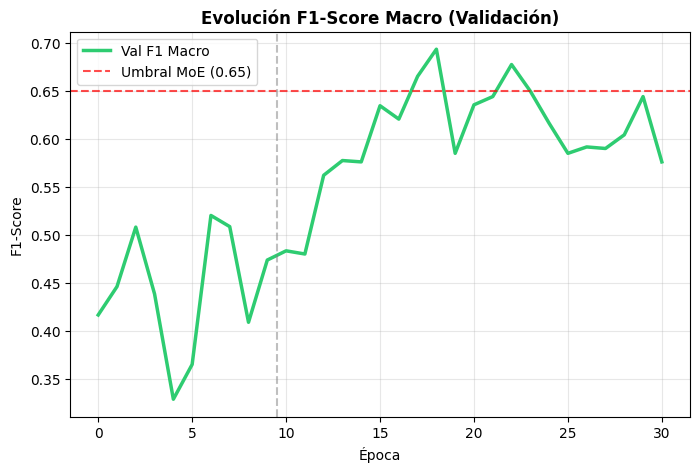

In [ ]:
# ----------------------------------------------------
# 3. Gráfica de F1-Score Macro Independiente
# ----------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(history['val_f1'], label='Val F1 Macro', color='#2ecc71', linewidth=2.5)
plt.axhline(y=0.65, color='red', linestyle='--', alpha=0.7, label='Umbral MoE (0.65)')
plt.axvline(x=fase_limite, color='gray', linestyle='--', alpha=0.5)
plt.title('Evolución F1-Score Macro (Validación)', fontweight='bold')
plt.xlabel('Época')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Se construyó una matriz de confusión a partir de las predicciones del modelo sobre el conjunto de prueba, permitiendo visualizar de forma clara cómo se distribuyen los aciertos y errores entre las distintas clases; mediante este enfoque se puede identificar no solo el rendimiento general, sino también en qué tipo de casos el modelo falla y con qué frecuencia, lo cual es clave en contextos clínicos donde cada error tiene un impacto significativo

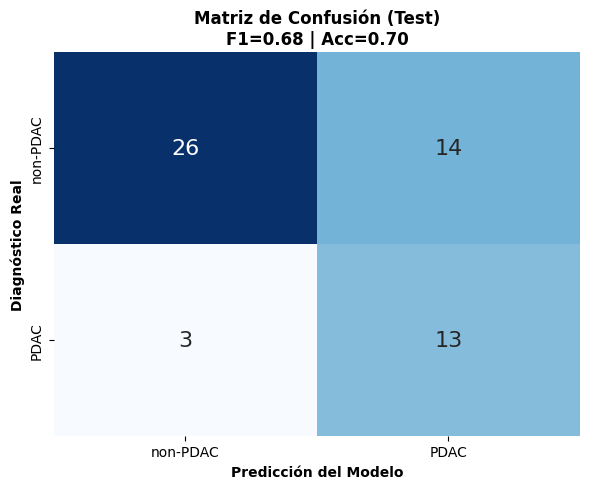

In [ ]:

# ----------------------------------------------------
# 4. Matriz de Confusión Mejorada (Diagnóstico Clínico)
# ----------------------------------------------------
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, annot_kws={"size": 16})
plt.xlabel('Predicción del Modelo', fontweight='bold')
plt.ylabel('Diagnóstico Real', fontweight='bold')
plt.title(f'Matriz de Confusión (Test)\nF1={test_f1:.2f} | Acc={test_acc:.2f}', fontweight='bold')
plt.tight_layout()
plt.show()

Ejecutamos una **EVALUACIÓN DE SENSIBILIDAD Y ESPECIFICIDAD DINÁMICA** para medir la capacidad de separación de clases del modelo mediante el análisis probabilístico.

La metodología de validación se divide en los siguientes puntos:

* **Construcción de la Curva ROC:** Se construyó la curva ROC a partir de las probabilidades generadas por el modelo, comparando la tasa de verdaderos positivos frente a la de falsos positivos para evaluar qué tan bien distingue entre clases; este enfoque permite analizar el comportamiento del modelo en distintos umbrales de decisión, en lugar de quedarse con un único punto como ocurre con accuracy.
* **Cálculo del AUC (Área Bajo la Curva):** Además, se calculó el AUC (Área Bajo la Curva), que resume en un solo valor la capacidad global de discriminación, donde valores cercanos a 1 indican un modelo sólido.

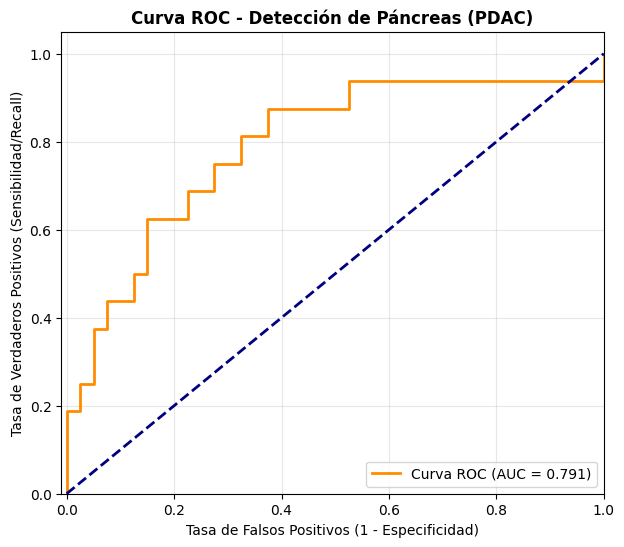

In [ ]:
# ----------------------------------------------------
# 5. Curva ROC (Receiver Operating Characteristic)
# ----------------------------------------------------
fpr, tpr, _ = roc_curve(all_labels, all_probs[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad/Recall)')
plt.title('Curva ROC - Detección de Páncreas (PDAC)', fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Ejecutamos una **EVALUACIÓN DE SENSIBILIDAD Y CONFIABILIDAD** para cuantificar el desempeño del modelo en la detección de casos positivos bajo condiciones de desbalance de datos.

La metodología de análisis se basa en el siguiente desarrollo técnico:

* **Relación entre Precisión y Recall:** En este apartado se generó la curva Precision-Recall, utilizando las probabilidades del modelo para analizar la relación entre la precisión (qué tan confiables son las predicciones positivas) y el recall (qué tantos casos reales logra detectar), algo fundamental cuando se trabaja con datos desbalanceados como en problemas clínicos; a diferencia de la curva ROC, aquí se pone mayor énfasis en el rendimiento sobre la clase positiva.

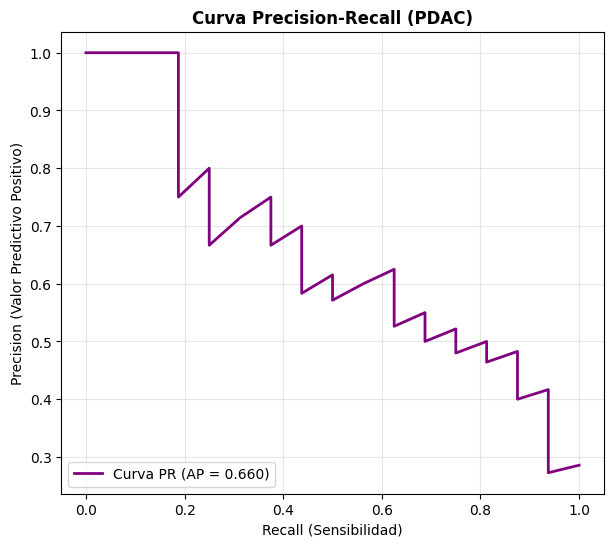

In [ ]:
# ----------------------------------------------------
# 6. Curva Precision-Recall (Crucial para Desbalance de Cáncer)
# ----------------------------------------------------
precision, recall, _ = precision_recall_curve(all_labels, all_probs[:, 1])
ap = average_precision_score(all_labels, all_probs[:, 1])

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, color='purple', lw=2, label=f'Curva PR (AP = {ap:.3f})')
plt.xlabel('Recall (Sensibilidad)')
plt.ylabel('Precision (Valor Predictivo Positivo)')
plt.title('Curva Precision-Recall (PDAC)', fontweight='bold')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

---
## 7. Resumen del Experto 5

| Propiedad | Valor |
|-----------|-------|
| Dataset | Pancreatic Cancer CT (PANORAMA) |
| Modelo | R3D-18 (Transfer Learning) |
| Input | 64x64x64 NPZ (HU normalizado + Kinetics 400 z-score) |
| Clases | 0=non-PDAC, 1=PDAC |
| Loss | FocalLoss (gamma=2.0) |
| Gradient Checkpointing | Obligatorio (ON) |
| FP16 Mixed Precision | ON |
| Umbral F1 Macro | > 0.65 (full) / > 0.58 (aceptable) |
